![KAUST Academy](https://i.imgur.com/a3uAqnb.png)

# Lab 3 — Transformers: 2017 vs 2026




## What this lab covers

This notebook builds intuition for the **Transformer architecture** and its modern extensions:
scaled dot-product attention, multi-head attention, RoPE, KV caching, grouped-query attention,
Mixture-of-Experts, RMSNorm

> The 2017 Transformer paper is small. 2026 systems reuse the same attention core with different
> position schemes, caches, and scaling tricks.

| Part | Question it answers | What you implement |
| :--- | :--- | :--- |
| **1** | Why did Transformers replace RNNs? | Scaled dot-product attention, multi-head attention |
| **2** | How does the model know word order? | Sinusoidal encodings, then RoPE |
| **3** | What makes generation expensive? | KV cache, grouped-query attention |
| **4** | How do models grow without growing compute? | A top-k MoE router with load balancing |
| **5** | Why did LLaMA drop LayerNorm? | RMSNorm |
| **6** | Postition of Normalization |PreLN vs PostLN |

**Parts 1 to 5 run on CPU in seconds. Part 6 downloads a model and is easier with a GPU**
(Runtime → Change runtime type → T4). A CPU-friendly option is provided there.

# Part 0 — Setup

## Installing the required libraries

- **PyTorch** — attention, RoPE, and KV-cache implementations.
- **Matplotlib / NumPy** — weight and encoding visualisation.
- **Transformers** — the vision-language model used in Part 6.

In [ ]:
!pip install -q torch torchaudio transformers datasets accelerate matplotlib numpy scipy

## Importing the essentials

These imports are used throughout every part below.

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)          # so every run of this notebook prints the same numbers

# Parts 1-5 are CPU-only; Part 6 uses this to place the vision-language model
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"PyTorch {torch.__version__}")
print(f"Device : {DEVICE}")

---

# Part 1 — Attention: the core that has not changed

## The question

Before 2017, sequence models were recurrent: to read the hundredth word, an RNN had to pass
information through ninety-nine intermediate states, one after another.

**Why did Transformers replace RNNs for sequence modelling at scale, and what is the mechanism that
made it possible?**

## Theory (A1)

**1. Why did Transformers replace RNNs for sequence modeling at scale?**

Transformers enable **parallel training** over sequence length, **direct long-range dependencies**
via attention (no vanishing path through time), and **better scaling** with data and compute
compared with RNNs.

**2. Write the scaled dot-product attention formula and explain the role of the scaling term.**

`Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V`. Scaling by `sqrt(d_k)` **prevents dot products
from growing large** with dimension, keeping softmax gradients stable.

**3. What is the purpose of masked self-attention in the decoder?**

**Masked** self-attention in the decoder prevents positions from attending to **future tokens**,
preserving **causal autoregressive** generation during training and inference.

## Implementation (B1) — scaled dot-product attention

Three inputs, four steps. The `mask` argument is what makes it causal: positions marked `True` are
set to negative infinity before the softmax, so they receive a weight of exactly zero.

In [ ]:
import torch
import torch.nn.functional as F
import math

torch.manual_seed(0)

# -------------------------------------------------
# Example sentence
# -------------------------------------------------

tokens = ["The", "cat", "chased", "the", "mouse"]

T = len(tokens)   # 5 tokens
D = 4             # vector size


# -------------------------------------------------
# 1) Create simple Q, K, V vectors
# -------------------------------------------------

Q = torch.randn(T, D)
K = torch.randn(T, D)
V = torch.randn(T, D)

print("TOKENS:")
print(tokens)

print("\nQ shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)


# -------------------------------------------------
# 2) Calculate raw attention scores
# QK^T / sqrt(D)
# -------------------------------------------------

scores = Q @ K.T / math.sqrt(D)

print("\n=== RAW ATTENTION SCORES ===")
print(scores.round(decimals=2))


# -------------------------------------------------
# 3) Apply causal mask
# Future tokens are blocked
# -------------------------------------------------

mask = torch.triu(
    torch.ones(T, T),
    diagonal=1
).bool()

print("\n=== CAUSAL MASK ===")
print(mask.int())

scores = scores.masked_fill(mask, float("-inf"))

print("\n=== SCORES AFTER MASK ===")
print(scores.round(decimals=2))


# -------------------------------------------------
# 4) Softmax -> attention probabilities
# -------------------------------------------------

weights = F.softmax(scores, dim=-1)

print("\n=== ATTENTION WEIGHTS ===")
print(weights.round(decimals=2))


# -------------------------------------------------
# 5) Combine Value vectors
# -------------------------------------------------

output = weights @ V

print("\nOutput shape:", output.shape)


# -------------------------------------------------
# 6) Easy-to-read result
# -------------------------------------------------

print("\n=== WHO DOES EACH TOKEN ATTEND TO? ===\n")

for i, token in enumerate(tokens):

    print(f"{token} looks at:")

    for j in range(i + 1):
        print(
            f"   {tokens[j]:>7} -> {weights[i, j]:.2f}"
        )

    print(f"   Sum = {weights[i].sum():.2f}")
    print()

## Implementation (B2) — Multi-Head Attention

**Multi-Head Attention** lets the model look at the same tokens in **different ways at the same time**.

Instead of one large attention head:

```text
d_model = 64
```

we split it into:

```text
4 heads × 16 dimensions = 64
```

Each head runs its own attention:

* **Head 1** may focus on syntax
* **Head 2** may focus on nearby words
* **Head 3** may focus on semantic relationships
* **Head 4** may focus on another pattern

Then the head outputs are **concatenated back together**.

**Key idea:** more attention perspectives, while the total width `d_model` stays the same.


In [ ]:
import torch
import torch.nn.functional as F
import math

# Example: 2 sentences, 8 tokens, d_model = 64
B, T, d_model, H = 2, 8, 64, 4
D = d_model // H                    # 16 dimensions per head

x = torch.randn(B, T, d_model)

# 1) Create Q, K, V
Q = torch.randn(B, T, d_model)
K = torch.randn(B, T, d_model)
V = torch.randn(B, T, d_model)

# 2) Split 64 dimensions into 4 heads × 16
Q = Q.view(B, T, H, D).transpose(1, 2)
K = K.view(B, T, H, D).transpose(1, 2)
V = V.view(B, T, H, D).transpose(1, 2)

# 3) Attention inside every head
scores = Q @ K.transpose(-2, -1) / math.sqrt(D)

mask = torch.triu(torch.ones(T, T), diagonal=1).bool()
scores = scores.masked_fill(mask, float("-inf"))

weights = F.softmax(scores, dim=-1)
out = weights @ V

# 4) Join the 4 heads back into 64 dimensions
out = out.transpose(1, 2).reshape(B, T, d_model)

print("Input :", x.shape)    # (2, 8, 64)
print("Heads :", Q.shape)    # (2, 4, 8, 16)
print("Output:", out.shape)  # (2, 8, 64)

## What just happened

The input and output have the **same shape**:

```text
Input  : (2, 8, 64)
Output : (2, 8, 64)
```

Inside the layer:

```text
d_model = 64
↓
4 heads × 16 dimensions
↓
Attention runs in each head
↓
Heads are joined back
↓
d_model = 64
```

**Key idea:** Multi-head attention is **not 4× the work** here.

```text
4 heads × 16 dimensions = 64
```

We keep the same total width, but split it so different heads can learn **different relationships at the same time**.

## In a nutshell

|                 | **2017**                            | **2026** |
| --------------- | ----------------------------------- | -------- |
| **Attention**   | `QKᵀ → Mask → Softmax → ×V`         | Same     |
| **Heads**       | Split `d_model` into multiple heads | Same     |
| **Causal Mask** | Blocks future tokens                | Same     |

**Takeaway:** the core Multi-Head Attention mechanism stayed almost unchanged.

Most modern improvements happen **around Attention**, not by replacing its core idea.

## Next

Attention knows **which tokens are related**, but by itself it does not know their order.

```text
"The cat chased the mouse"
```

So the next question is:

> **How does the model know where each token is in the sequence?**

That is **Part 2 — Positional Encoding and RoPE**.


# Part 2 — Position: sinusoidal encodings, then RoPE

## The question

The original Transformer has **no recurrence**, so order has to come from somewhere else. Without
it, "the dog chased the cat" and "the cat chased the dog" are the same set of tokens and produce the
same representation.

**How is position injected, and why did the method change?**

## Theory (A2.1) — Sinusoidal vs RoPE

Both methods give the model **position information**, but they do it differently.

### 1. Sinusoidal Position Encoding

Token embedding  
↓  
Add a fixed position vector  
↓  
Send into the Transformer  

**Main idea:** **"Where am I?"**  
It focuses on the token's **absolute position**.

Example:

Position 10 → has its own position pattern  
Position 5000 → has a very different position pattern  

---

### 2. RoPE — Rotary Position Embedding

Q and K vectors  
↓  
Rotate them based on their positions  
↓  
Compute attention  
↓  
The score naturally reflects **relative distance**

**Main idea:** **"How far are we apart?"**

Example:

Position 10 → Position 13 = **distance 3**  
Position 5000 → Position 5003 = **distance 3**

With **RoPE**, both relationships are represented similarly because the **relative distance is the same**.

---

### Takeaway

- **Sinusoidal:** mainly represents **absolute position** → "Where am I?"
- **RoPE:** naturally represents **relative position** → "How far are we apart?"
- **RoPE** is better suited for **long-context models**.

## Implementation (B7) — sinusoidal positional encoding, the 2017 baseline

The original scheme builds one fixed row per position from sines and cosines at different
frequencies, and adds that row to the token embedding at the input.

We then verify the property it was designed to have: nearby positions should receive **more similar**
encodings than distant ones.

In [ ]:
import torch
import math

# Small helper: classic 2017 sinusoidal positional encoding
def sinusoidal_pe(seq_len, d_model):
    pos = torch.arange(seq_len)[:, None]
    i = torch.arange(0, d_model, 2)

    angle = pos / (10000 ** (i / d_model))

    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(angle)
    pe[:, 1::2] = torch.cos(angle)
    return pe

# Real-word example
tokens = ["The", "cat", "chased", "the", "mouse"]
T, D = len(tokens), 4

token_embeddings = torch.randn(T, D)
position_encoding = sinusoidal_pe(T, D)

# Add position information to each token
x = token_embeddings + position_encoding

print("Tokens:", tokens)
print("Position Encoding shape:", position_encoding.shape)  # (5, 4)
print("Final Input shape:", x.shape)                        # (5, 4)

print("\nPosition patterns:")
for token, pe in zip(tokens, position_encoding):
    print(f"{token:>7} -> {pe.round(decimals=2).tolist()}")

## Implementation (B3) — RoPE

**RoPE adds position information by rotating Query and Key vectors instead of adding a position vector.**

<div align="center">

Token position  
↓  
Rotate **Q** and **K**  
↓  
Compute `Q · K`  
↓  
Attention depends on **relative distance**

</div>

### Key idea

If:

**Query is at position `m`**  
**Key is at position `n`**

then the attention relationship depends mainly on:

**`m - n`**

So RoPE helps the model understand:

> **How far apart are these two tokens?**

### Takeaway

**Sinusoidal:** add position to embeddings  
**RoPE:** rotate Q/K using position  

**RoPE → better relative-position information for modern LLMs**

In [ ]:
import torch
import math

# Simple RoPE for one sequence: x shape = (tokens, dimensions)
def rope(x, positions):
    D = x.shape[-1]

    # Split dimensions into pairs: (0,1), (2,3), ...
    even = x[:, 0::2]
    odd  = x[:, 1::2]

    # Different rotation speed for each pair
    freq = 1.0 / (10000 ** (torch.arange(0, D, 2).float() / D))
    angle = positions[:, None] * freq[None, :]

    # Rotate each pair
    out = torch.empty_like(x)
    out[:, 0::2] = even * torch.cos(angle) - odd * torch.sin(angle)
    out[:, 1::2] = even * torch.sin(angle) + odd * torch.cos(angle)

    return out


# Example: same sentence positions
tokens = ["The", "cat", "chased", "the", "mouse"]
T, D = len(tokens), 4

x = torch.randn(T, D)
positions = torch.arange(T)

x_rope = rope(x, positions)

print("Tokens :", tokens)
print("Input  :", x.shape)
print("Output :", x_rope.shape)


# Test relative position
q = torch.randn(1, D)
k = torch.randn(1, D)

print("\nSame Q and K, always distance = 4:")

for q_pos, k_pos in [(0, 4), (10, 14), (50, 54), (200, 204)]:
    q_rot = rope(q, torch.tensor([q_pos]))
    k_rot = rope(k, torch.tensor([k_pos]))

    score = (q_rot * k_rot).sum()

    print(f"{q_pos:>3} → {k_pos:<3} | distance = 4 | score = {score:.4f}")

## What just happened

The **same Q and K**, kept **4 positions apart**, produced the **same attention score** at positions `0→4`, `10→14`, `50→54`, and `200→204`.

**Why?** RoPE makes attention depend mainly on the **relative distance**, not the absolute position.

### In a nutshell

| | **Sinusoidal** | **RoPE** |
|---|---|---|
| Operation | Add position vector | Rotate Q and K |
| Encodes | Absolute position | Relative distance |
| Applied | Once at input | Every attention layer |
| Long context | Weaker extrapolation | Better suited for long context |

**Takeaway:**  
**Sinusoidal → "Where am I?"**  
**RoPE → "How far are we apart?"**

## Next

During generation, the model repeatedly uses information from previous tokens.

> **What can we cache instead of recomputing every time?**

That is **Part 3 — KV Cache**.

# Part 3 — Inference cost: the KV cache and grouped-query attention

## The question

To generate token 100, the model runs attention over the 99 tokens before it. To generate token 101,
it runs attention over 100 tokens. The keys and values of those earlier tokens have not changed.

**Why compute them again, and once we stop, what new problem appears?**

## Theory (A2.2)

**What is stored in the KV cache during autoregressive inference, and how does it reduce cost?**

The **KV cache** stores past **keys and values** for all layers so each new token only computes QKV
for itself and attends to cached history — cost per step grows linearly with context but avoids
recomputing full sequence attention.

## Implementation (B4) — one decode step reusing the cache

The cache is deliberately simple: keep the keys and values seen so far, and concatenate the new
token's key and value onto them along the sequence dimension.

In [ ]:
import torch

# Simple KV Cache
class KVCache:
    def __init__(self):
        self.keys = []
        self.values = []

    def update(self, token, k, v):
        self.keys.append(k)
        self.values.append(v)

        print(f"Added token: {token}")
        print(f"Cache now  : {len(self.keys)} token(s)\n")


# Example generation
tokens = ["The", "cat", "is", "sleeping"]
cache = KVCache()

for token in tokens:
    # Fake K and V for this new token
    k = torch.randn(4)
    v = torch.randn(4)

    cache.update(token, k, v)

## What just happened

The **KV Cache grows by one token at each decoding step**.

Without cache:

`1 + 2 + ... + 1000 = 500,500` K/V computations

With cache:

`1000` K/V computations

**Benefit:** reuse old K/V instead of recomputing them.

**Cost:** the cache keeps growing in **GPU memory** as the context gets longer.

**Takeaway:**  
**KV Cache → much less recomputation, but more memory usage.**

## Theory (A2.2) — Why GQA?

During **inference**, the model stores the **K and V vectors of previous tokens** inside the **KV Cache**.

With standard **Multi-Head Attention (MHA)**, every Query head has its own K/V head:

Q1 → K1, V1  
Q2 → K2, V2  
Q3 → K3, V3  
Q4 → K4, V4  

More K/V heads means a **larger KV Cache**.

**Grouped-Query Attention (GQA)** reduces this memory by letting several Query heads **share the same K/V heads**:

Q1 ─┐  
Q2 ─┘ → K1, V1  

Q3 ─┐  
Q4 ─┘ → K2, V2  

The Query heads are still separate, so the model keeps multiple attention views, but it stores fewer K/V vectors.

**Key idea:**  
**GQA = keep many Query heads + reduce K/V heads → smaller KV Cache**

This mainly improves **inference memory and serving cost** without changing the core attention calculation.

### Transformer Architecture (Alternative View)

<img src="https://www.researchgate.net/publication/392766420/figure/fig3/AS:11431281504901334@1750216700321/provides-a-visual-representation-of-MHA-GQA-and-MQA-types-of-model-attention-heads.ppm" width="800">

## Implementation (B8) — Grouped-Query Attention (GQA)


In [ ]:
import torch
import torch.nn.functional as F
import math

# Example
B, T = 1, 5
d_model = 64
q_heads = 8
kv_heads = 2
d_head = d_model // q_heads   # 8

x = torch.randn(B, T, d_model)

# =================================================
# BEFORE: MHA
# 8 Q heads, 8 K heads, 8 V heads
# =================================================

Wq_mha = torch.nn.Linear(d_model, q_heads * d_head)
Wk_mha = torch.nn.Linear(d_model, q_heads * d_head)
Wv_mha = torch.nn.Linear(d_model, q_heads * d_head)

Q_mha = Wq_mha(x).view(B, T, q_heads, d_head).transpose(1, 2)
K_mha = Wk_mha(x).view(B, T, q_heads, d_head).transpose(1, 2)
V_mha = Wv_mha(x).view(B, T, q_heads, d_head).transpose(1, 2)

print("=== BEFORE: MHA ===")
print("Q shape:", Q_mha.shape)   # (1, 8, 5, 8)
print("K shape:", K_mha.shape)   # (1, 8, 5, 8)
print("V shape:", V_mha.shape)   # (1, 8, 5, 8)


# =================================================
# AFTER: GQA
# 8 Q heads, but only 2 K/V heads
# =================================================

Wq_gqa = torch.nn.Linear(d_model, q_heads * d_head)
Wk_gqa = torch.nn.Linear(d_model, kv_heads * d_head)
Wv_gqa = torch.nn.Linear(d_model, kv_heads * d_head)

Q_gqa = Wq_gqa(x).view(B, T, q_heads, d_head).transpose(1, 2)
K_gqa = Wk_gqa(x).view(B, T, kv_heads, d_head).transpose(1, 2)
V_gqa = Wv_gqa(x).view(B, T, kv_heads, d_head).transpose(1, 2)

print("\n=== AFTER: GQA ===")
print("Q shape:", Q_gqa.shape)   # (1, 8, 5, 8)
print("K shape:", K_gqa.shape)   # (1, 2, 5, 8)
print("V shape:", V_gqa.shape)   # (1, 2, 5, 8)


# =================================================
# Share K/V across Query heads
# Q0-Q3 share K0/V0
# Q4-Q7 share K1/V1
# =================================================

group_size = q_heads // kv_heads   # 4

K_shared = K_gqa.repeat_interleave(group_size, dim=1)
V_shared = V_gqa.repeat_interleave(group_size, dim=1)

scores = Q_gqa @ K_shared.transpose(-2, -1) / math.sqrt(d_head)
weights = F.softmax(scores, dim=-1)
output = weights @ V_shared

print("\n=== SHARING ===")
print("Q0-Q3 -> K0,V0")
print("Q4-Q7 -> K1,V1")

print("\nOutput shape:", output.shape)   # (1, 8, 5, 8)


# =================================================
# KV Cache comparison
# =================================================

mha_cache = K_mha.numel() + V_mha.numel()
gqa_cache = K_gqa.numel() + V_gqa.numel()

print("\n=== KV CACHE ===")
print("MHA cache:", mha_cache, "elements")
print("GQA cache:", gqa_cache, "elements")
print(f"GQA is {mha_cache / gqa_cache:.1f}x smaller")

## Part 4 — Mixture-of-Experts (MoE)

### The problem

In a **dense model**, every token uses the same full set of parameters.

<div align="center">

Token: `"Python"`

↓

Use all FFN parameters

↓

Output

</div>

So if the model becomes larger:

<div align="center">

**10B parameters → 20B parameters**

**More parameters → more compute per token**

</div>

---

### The MoE idea

**Mixture-of-Experts (MoE)** separates **total model capacity** from **active compute**.

Instead of one large FFN, we use several **Experts** and a **Router**.

<div align="center">

Token: `"Python"`

↓

**Router**

↓

Choose only the best Experts

↓

**Expert 2 + Expert 6**

↓

Output

</div>

The other Experts are **not used for this token**.

---

### Example

Suppose we have:

<div align="center">

**8 Experts × 10B parameters = 80B total parameters**

</div>

But the Router selects only **2 Experts per token**:

<div align="center">

**2 Experts × 10B = 20B active parameters**

</div>

So:

<div align="center">

**Total capacity = 80B**

**Active compute per token ≈ 20B**

</div>

The model has much more capacity without activating every parameter for every token.

---

### Dense vs MoE

| **Dense** | **MoE** |
|---|---|
| Token | Token |
| ↓ | ↓ |
| All parameters | Router |
| ↓ | ↓ |
| Output | Select a few Experts |
|  | ↓ |
|  | Output |

---

### Takeaway

- **Dense:** every token uses all relevant parameters → larger model means more compute.
- **MoE:** every token uses only selected Experts → much larger total model with lower active compute.
- **Core idea:** **More capacity without proportional compute per token.**

<div align="center">
  <img src="https://miro.medium.com/v2/resize:fit:4800/format:webp/1*3o1bWOzFp7BsWaXyK7lj-A.gif" width="600">
</div>

### How do the Experts work?

Each **Expert** is usually a separate **Feed-Forward Network (FFN)** with its own learned parameters.

A useful mental model is:

<div align="center">

User asks:

**"How do I sort a list in Python?"**

↓

Token representations enter the MoE layer

↓

**Router scores all Experts**

↓

Select the **Top-2 Experts**

↓

**Expert 2 + Expert 6**

↓

Their outputs are combined

↓

Next Transformer layer

</div>

---

### What does each Expert represent?

Experts are **not manually assigned** roles like:

<div align="center">

Expert 1 = Math  
Expert 2 = Python  
Expert 3 = English  

</div>

Instead, during **training**, each Expert learns different patterns automatically.

For example, after training, we might observe something like:

| Expert | May become better at |
|---|---|
| Expert 1 | Mathematical patterns |
| Expert 2 | Programming patterns |
| Expert 3 | Language structure |
| Expert 4 | Factual / knowledge patterns |
| Expert 5 | Reasoning patterns |

But this specialization is **learned**, not explicitly programmed.

---

### Example

Suppose the input contains:

<div align="center">

**"Python sort list"**

↓

Router

↓

Expert 2 score = **0.72**  
Expert 6 score = **0.21**  
Others = lower scores

↓

Select **Expert 2 + Expert 6**

↓

Both Experts process the token

↓

Weighted combination of their outputs

</div>

So the Router decides **which Experts are most useful for each token**.

---

### Important

The selection happens **per token**, not necessarily per whole question.

For example:

<div align="center">

`"Calculate 25 * 4 using Python"`

</div>

Different tokens may be routed differently:

<div align="center">

`Calculate` → Expert 1 + Expert 5  

`25` → Expert 1 + Expert 3  

`Python` → Expert 2 + Expert 6  

</div>

---

### Takeaway

**Expert** = its own learned FFN parameters  

**Router** = decides which Experts each token should use  

**Training** = Experts gradually learn different useful patterns  

**MoE** = many Experts exist, but only a few are activated for each token

## Implementation (B5) — a top-k router with load balancing

The layer holds `n_experts` small feed-forward networks. A **router** scores each token against every
expert, the top `k` experts are selected, and only those run.

The `load_loss` at the end measures how unevenly the experts were used. It is needed because routers
left alone will collapse onto a few favourite experts, leaving the rest untrained.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)

# =========================================================
# Example question
# "Calculate 25 * 4 using Python"
# =========================================================

tokens = ["Calculate", "25", "*", "4", "using", "Python"]

# For teaching only, each token has 4 simple features:
# [Math, Programming, Language, Reasoning]
x = torch.tensor([
    [0.8, 0.1, 0.2, 0.7],   # Calculate
    [1.0, 0.0, 0.0, 0.4],   # 25
    [1.0, 0.1, 0.0, 0.3],   # *
    [1.0, 0.0, 0.0, 0.4],   # 4
    [0.1, 0.3, 0.8, 0.2],   # using
    [0.1, 1.0, 0.3, 0.4],   # Python
], dtype=torch.float32)


# =========================================================
# MoE Layer
# =========================================================

class MoELayer(nn.Module):
    def __init__(self, d_model=4, n_experts=4, top_k=2):
        super().__init__()

        self.top_k = top_k
        self.n_experts = n_experts

        # Router: scores every token for every expert
        self.router = nn.Linear(d_model, n_experts, bias=False)

        # 4 separate FFN Experts
        self.experts = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d_model, 8),
                nn.ReLU(),
                nn.Linear(8, d_model)
            )
            for _ in range(n_experts)
        ])

    def forward(self, x):

        # 1) Router scores
        logits = self.router(x)

        # 2) Select Top-K experts
        topk = torch.topk(logits, self.top_k, dim=-1)

        expert_ids = topk.indices
        weights = F.softmax(topk.values, dim=-1)

        # 3) Run only selected experts
        output = torch.zeros_like(x)
        usage = torch.zeros(self.n_experts)

        for token_id in range(x.size(0)):

            for k in range(self.top_k):

                expert_id = expert_ids[token_id, k].item()
                weight = weights[token_id, k]

                expert_output = self.experts[expert_id](
                    x[token_id]
                )

                output[token_id] += weight * expert_output
                usage[expert_id] += 1

        # 4) Load-balancing measurement
        load_loss = usage.std() / (usage.mean() + 1e-8)

        return output, expert_ids, weights, usage, load_loss


# =========================================================
# Create MoE
# =========================================================

moe = MoELayer(
    d_model=4,
    n_experts=4,
    top_k=2
)


with torch.no_grad():
    moe.router.weight.copy_(torch.eye(4))


expert_names = [
    "Math",
    "Programming",
    "Language",
    "Reasoning"
]


# =========================================================
# Forward pass
# =========================================================

output, selected, weights, usage, load_loss = moe(x)


# =========================================================
# Show what happened
# =========================================================

print('Question: "Calculate 25 * 4 using Python"\n')

for i, token in enumerate(tokens):

    e1 = selected[i, 0].item()
    e2 = selected[i, 1].item()

    w1 = weights[i, 0].item()
    w2 = weights[i, 1].item()

    print(f"Token: {token}")
    print("   ↓ Router")
    print(f"   ├─ {expert_names[e1]:11s}  weight = {w1:.2f}")
    print(f"   └─ {expert_names[e2]:11s}  weight = {w2:.2f}")
    print()


# =========================================================
# Expert usage
# =========================================================

print("=== Expert Usage ===")

for name, count in zip(expert_names, usage):
    print(f"{name:11s}: {int(count.item())} selections")

print(f"\nLoad-balance loss: {load_loss.item():.3f}")
print("Output shape:", output.shape)

# Part 5 — RMSNorm: the Same Job with Fewer Operations

Both **LayerNorm** and **RMSNorm** control activation scale, but RMSNorm uses simpler math.

---

## LayerNorm

For an input vector `x`:

**Mean**

$$
\mu = \frac{1}{d}\sum_{i=1}^{d} x_i
$$

**Variance**

$$
\sigma^2 = \frac{1}{d}\sum_{i=1}^{d}(x_i-\mu)^2
$$

**LayerNorm**

$$
\mathrm{LayerNorm}(x)
=
\gamma
\frac{x-\mu}{\sqrt{\sigma^2+\epsilon}}
+
\beta
$$

<div align="center">

**Subtract mean → Normalize variance → Scale with γ → Add bias β**

</div>

---

## RMSNorm

RMSNorm does **not subtract the mean**.

**Root Mean Square**

$$
\mathrm{RMS}(x)
=
\sqrt{
\frac{1}{d}\sum_{i=1}^{d}x_i^2+\epsilon
}
$$

**RMSNorm**

$$
\mathrm{RMSNorm}(x)
=
\gamma
\frac{x}{\mathrm{RMS}(x)}
$$

<div align="center">

**Square → Mean → Square root → Divide → Scale with γ**

</div>

Usually there is **no bias β**.

---

## Difference

### LayerNorm

$$
\boxed{
\mathrm{LayerNorm}(x)
=
\gamma
\frac{x-\mu}{\sqrt{\sigma^2+\epsilon}}
+
\beta
}
$$

### RMSNorm

$$
\boxed{
\mathrm{RMSNorm}(x)
=
\gamma
\frac{x}{
\sqrt{
\frac{1}{d}\sum_{i=1}^{d}x_i^2+\epsilon
}
}
}
$$

| | **LayerNorm** | **RMSNorm** |
|---|---|---|
| Subtract mean | ✅ | ❌ |
| Variance | ✅ | ❌ |
| RMS | ❌ | ✅ |
| Learnable scale `γ` | ✅ | ✅ |
| Learnable bias `β` | ✅ | Usually ❌ |

### Takeaway

<div align="center">

**LayerNorm = Center + Scale**

**RMSNorm = Scale only → simpler computation**

</div>

## Why is RMSNorm often preferred?

RMSNorm keeps the useful normalization effect while doing **less computation**.

<div align="center">

**LayerNorm**

Center + Scale

↓

Subtract mean + Normalize variance

</div>

<div align="center">

**RMSNorm**

Scale only

↓

Normalize using RMS

</div>

### Why can RMSNorm be better?

- **Fewer operations** → no mean subtraction
- **Simpler computation** → usually no bias `β`
- **Slightly faster** → important because normalization runs in every Transformer block
- **Works well in modern LLMs** → scale normalization is often sufficient for stable training

### Important

RMSNorm is not always universally better.

It is mainly a **simpler and more efficient alternative** to LayerNorm that works very well in many modern Transformer architectures.

### Takeaway

<div align="center">

**LayerNorm = Center + Scale**

**RMSNorm = Scale only → simpler and more efficient**

</div>

## Implementation (B6) — RMSNorm against LayerNorm

RMSNorm divides by the root mean square and applies a learned scale. No mean, no bias. We build it
and compare the activation statistics against PyTorch's `LayerNorm` on the same input.

In [ ]:
class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))
        self.eps = eps

    def forward(self, x):
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return self.weight * x / rms


x = torch.randn(32, 64) * 5          # deliberately badly scaled input
ln = nn.LayerNorm(64)
rn = RMSNorm(64)

print(f"LayerNorm std: {ln(x).std():.3f} | RMSNorm std: {rn(x).std():.3f}")

# where the two actually differ
print(f"\nLayerNorm learnable tensors: {sum(1 for _ in ln.parameters())} (weight and bias)")
print(f"RMSNorm   learnable tensors: {sum(1 for _ in rn.parameters())} (weight only)")

# Part 6 — Post-LN vs Pre-LN vs ResiDual

### Why does this matter?

The original Transformer used **Post-LN**, which made deep training less stable and often required **learning-rate warm-up**.

---

### Post-LN — 2017

<div align="center">

`x → F(x) → Add Residual → LayerNorm`

`x_next = LN(x + F(x))`

</div>

- LayerNorm is **after** the residual addition
- Gradient flow is harder
- Warm-up is often needed

---

### Pre-LN — Modern common choice

<div align="center">

`x → LayerNorm → F → Add Residual`

`x_next = x + F(LN(x))`

</div>

- LayerNorm is **before** `F`
- Residual path stays clear
- Easier and more stable training

---

### ResiDual

Uses **two residual paths** to combine benefits of Post-LN and Pre-LN.

---

### Takeaway

| Method | Main idea |
|---|---|
| **Post-LN** | Original, harder optimization |
| **Pre-LN** | Better gradient flow, easier training |
| **ResiDual** | Tries to combine both |

<div align="center">

**2017 → Post-LN**  
**Modern LLMs → mostly Pre-LN-style designs**

</div>

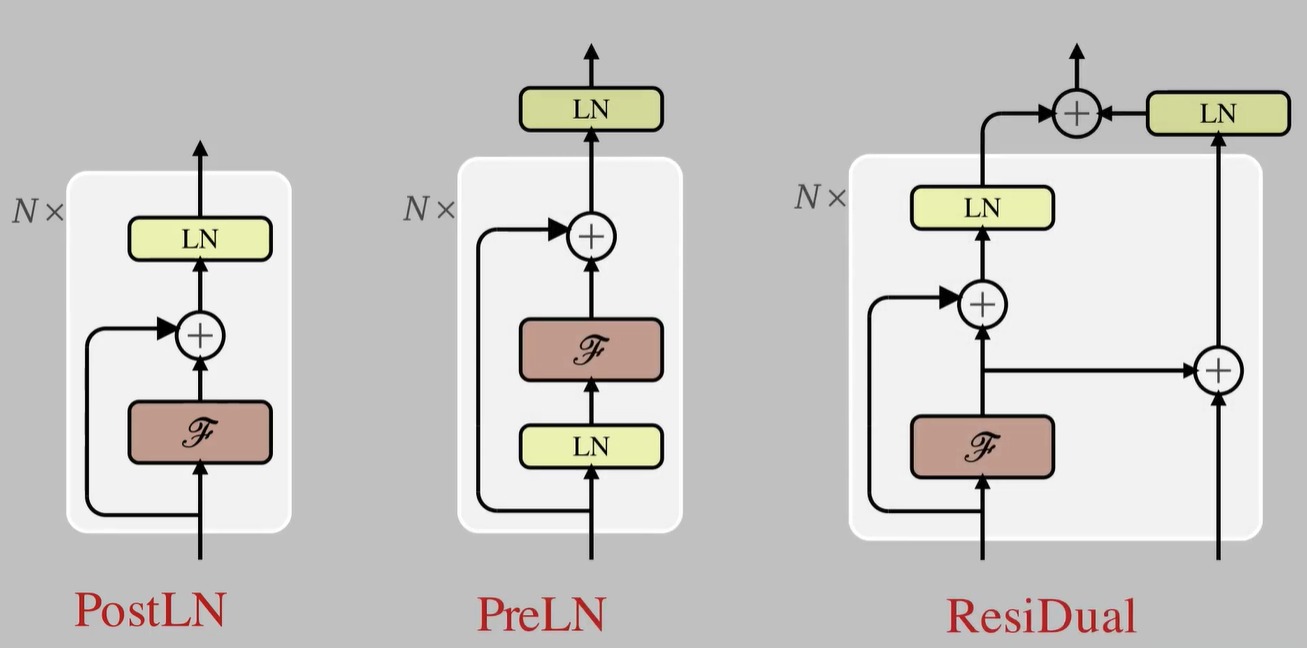

*Left to right: **PostLN**, **PreLN**, **ResiDual**. Follow the vertical line that runs from the
bottom of each block to the top — that is the residual path. In PostLN it passes **through** an LN
box. In PreLN the LN box has moved off to the side, into the branch. In ResiDual there are two
paths, and the right-hand one is completely clear.*

## Implementation — how much gradient reaches the bottom

Same idea, measured the other way round: build the stack in both arrangements, backpropagate once,
and look at the size of the gradient arriving at the very first layer.

In [ ]:
import torch
import torch.nn as nn

torch.manual_seed(0)

width = 8
depth = 12

# Same layers for both
layers = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
norms  = nn.ModuleList([nn.LayerNorm(width) for _ in range(depth)])


# -------------------------------------------------
# Post-LN
# x -> F -> Add -> Norm
# -------------------------------------------------

x_post = torch.randn(1, width, requires_grad=True)
h = x_post

for i in range(depth):
    h = norms[i](h + layers[i](h))

loss = h.pow(2).sum()
loss.backward()

post_grad = x_post.grad.norm().item()


# -------------------------------------------------
# Pre-LN
# x -> Norm -> F -> Add
# -------------------------------------------------

x_pre = x_post.detach().clone().requires_grad_(True)
h = x_pre

for i in range(depth):
    h = h + layers[i](norms[i](h))

loss = h.pow(2).sum()
loss.backward()

pre_grad = x_pre.grad.norm().item()


# -------------------------------------------------
# Compare
# -------------------------------------------------

print("Gradient reaching the INPUT\n")

print(f"Post-LN gradient: {post_grad:.6f}")
print(f"Pre-LN  gradient: {pre_grad:.6f}")

print("\nBigger gradient means:")
print("the training signal reached the early layers more easily.")

## In a nutshell

| | **Post-LN** | **Pre-LN** | **ResiDual** |
|---|---|---|---|
| Formula | `LN(x + F(x))` | `x + F(LN(x))` | Dual residual paths |
| Gradient flow | Harder | Easier | Easier |
| Warm-up | Often needed | Less critical | Less critical |
| Main trade-off | Strong quality, harder training | Stable training | Tries to combine both |

### Key idea

**Post-LN:** LayerNorm is on the residual path → gradient flow is harder.

**Pre-LN:** residual path stays clear → easier training in deep Transformers.

<div align="center">

**Post-LN → better tuned quality, harder optimization**  
**Pre-LN → easier optimization, possible representation issues**

</div>

# Part 7 — Recap

## The four things to remember

1. **The attention core was never replaced.** Scaled dot-product attention and multi-head attention
   are the 2017 design. Every other part of this lab is a change made around them.

2. **Position moved from addition to rotation.** The RoPE cell showed four identical scores for the
   same distance at four different absolute positions. Sinusoidal encodings cannot do that, and that
   difference is what long context is built on.

3. **The KV cache trades compute for memory.** It removes an enormous amount of repeated work, and
   in exchange the cache itself becomes the thing that fills the GPU. Grouped-query attention is the
   response, worth exactly `n_q_heads / n_kv_heads`.

4. **Two changes were about separating capacity from cost.** MoE decouples parameters from compute
   per token. RMSNorm removes work that measurement showed was not contributing.



###### Contributed by: Hussain alyafei